# Telco Customer Churn - Exploratory Data Analysis & Dataset Understanding

This notebook performs an initial exploratory data analysis (EDA) and dataset understanding on the **Telco Customer Churn** dataset from Kaggle. It covers dimensions, data profiling, type correction, data integrity checks, target variable distribution analysis, and high-cardinality checks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries successfully imported.")

Libraries successfully imported.


## 1. Load Dataset & Dimensions

We load the dataset from the CSV file and print its structural dimensions (number of rows and columns).

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset Dimensions:")
print(f" - Total Rows (Records): {df.shape[0]}")
print(f" - Total Columns (Features): {df.shape[1]}")

# Display first few rows
df.head()

Dataset Dimensions:
 - Total Rows (Records): 7043
 - Total Columns (Features): 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Type Profiling & TotalCharges Correction

We inspect the raw data types to profile continuous numerical features, discrete numerical features, and categorical features (nominal vs. ordinal).

In [3]:
# Profile raw data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### TotalCharges Conversion & Finding Documentation

> **Observation**: `TotalCharges` is stored as an `object` (string) in the raw dataset, but it represents continuous monetary values. 
>
> Let's investigate if there are non-numeric characters (such as blank spaces) preventing conversion to float, convert the column, and document our findings.

In [4]:
# Identify rows with blank spaces in TotalCharges
blank_total_charges = df[df['TotalCharges'].str.strip() == '']
print(f"Number of blank spaces in TotalCharges: {len(blank_total_charges)}")

# Inspect blank rows
if len(blank_total_charges) > 0:
    print("\nRows with blank TotalCharges:")
    display(blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

# Convert TotalCharges to float, replacing blank spaces with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
print(f"\nTotalCharges type after conversion: {df['TotalCharges'].dtype}")

Number of blank spaces in TotalCharges: 11
Rows with blank TotalCharges:
TotalCharges type after conversion: float64


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


### Feature Classification

Following type profiling and correction, we classify the features into their respective types:

1. **Continuous Numerical Features**:
   * `tenure` (duration in months)
   * `MonthlyCharges` (current monthly fee)
   * `TotalCharges` (total cumulative fee, corrected to float)
2. **Discrete Numerical Features**:
   * `SeniorCitizen` (binary discrete indicator: `0` or `1`)
3. **Nominal Categorical Features** (no inherent hierarchy/ordering):
   * `customerID` (unique identifier)
   * `gender`, `Partner`, `Dependents`
   * `PhoneService`, `MultipleLines`
   * `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
   * `PaperlessBilling`, `PaymentMethod`
   * `Churn` (Target Variable)
4. **Ordinal Categorical Features** (ordered hierarchy):
   * `Contract`: Ordered hierarchy (`Month-to-month` < `One year` < `Two year`)

In [5]:
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
discrete_features = ['SeniorCitizen']
nominal_features = [
    'customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]
ordinal_features = ['Contract']

print(f"Continuous features: {continuous_features}")
print(f"Discrete features: {discrete_features}")
print(f"Nominal features: {nominal_features}")
print(f"Ordinal features: {ordinal_features}")

Continuous features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Discrete features: ['SeniorCitizen']
Nominal features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Ordinal features: ['Contract']


## 3. Data Integrity Check

We perform structural sanity checks, counting missing (null) values per column and searching for duplicate records.

In [6]:
# Count missing values per column
print("Missing (null) values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicate_count}")

Missing (null) values per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Total duplicate rows found: 0


### Observation on Data Integrity

* **Duplicate Rows**: No duplicate rows exist in the dataset, ensuring each row represents a unique account.
* **Missing Values**: The only missing values are the **11 NaN values in `TotalCharges`** resulting from the blank space correction.
* **Critical Formatting Finding**: All 11 records with missing `TotalCharges` have a `tenure` of **`0`** months. This indicates these are brand-new customers who have signed up but have not yet been billed. 
  * *Action plan for modeling*: Since these customers have `tenure = 0` and are active, their `TotalCharges` can be safely imputed with `0.0` or dropped during data cleaning.

## 4. Target Variable Analysis

We analyze the distribution of the target variable `Churn` to evaluate class balance.

Churn Target Distribution:
 - No: 5174 (73.46%)
 - Yes: 1869 (26.54%)


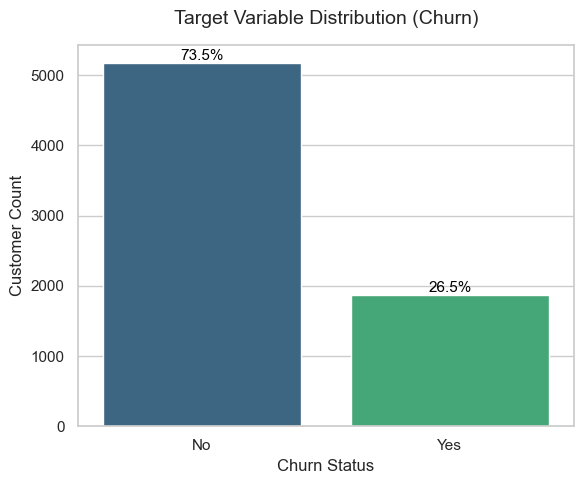

In [7]:
# Calculate count and percentage distribution
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("Churn Target Distribution:")
for label, count, pct in zip(churn_counts.index, churn_counts.values, churn_percentages.values):
    print(f" - {label}: {count} ({pct:.2f}%)")

# Plot Target Distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title('Target Variable Distribution (Churn)', fontsize=14, pad=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Customer Count', fontsize=12)

# Add percentage labels on top of the bars
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., height + 100), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 0),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('churn_distribution_chart.png', dpi=100)
plt.show()

### Observation on Class Imbalance

* **Class Breakdown**: `No Churn` comprises **$73.46\%$** of the dataset ($5,174$ instances), while `Churn` comprises **$26.54\%$** ($1,869$ instances).
* **Is Class Imbalance a Concern?**
  * **Yes**. A ~3:1 ratio represents a moderate class imbalance. 
  * If we optimize for raw **Accuracy**, a dummy model predicting `No` for everyone would achieve **$73.46\%$** accuracy but detect zero churners.
  * For a business-driven retention strategy, we must focus on **Recall** (capturing as many actual churners as possible) and **F1-Score**. 
  * Consequently, modeling must handle this imbalance using options like **stratified cross-validation**, cost-sensitive training (e.g., setting **`class_weight='balanced'`** in models), or resampling techniques like **SMOTE**.

## 5. High-Cardinality Check

High-cardinality categorical features can lead to dimensional explosion during encoding (e.g., one-hot encoding). We check the unique value count for each categorical column.

In [8]:
# List unique value counts for all categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Contract' not in categorical_cols: 
    categorical_cols.append('Contract')

print("Categorical Column Cardinality Counts:")
high_cardinality_cols = []
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f" - {col}: {unique_count} unique values")
    if unique_count > 10:
        high_cardinality_cols.append(col)

print(f"\nFlagged High-Cardinality Columns (> 10 values): {high_cardinality_cols}")

Categorical Column Cardinality Counts:
 - customerID: 7043 unique values
 - gender: 2 unique values
 - Partner: 2 unique values
 - Dependents: 2 unique values
 - PhoneService: 2 unique values
 - MultipleLines: 3 unique values
 - InternetService: 3 unique values
 - OnlineSecurity: 3 unique values
 - OnlineBackup: 3 unique values
 - DeviceProtection: 3 unique values
 - TechSupport: 3 unique values
 - StreamingTV: 3 unique values
 - StreamingMovies: 3 unique values
 - Contract: 3 unique values
 - PaperlessBilling: 2 unique values
 - PaymentMethod: 4 unique values
 - Churn: 2 unique values
Flagged High-Cardinality Columns (> 10 values): ['customerID']


### Observation on High Cardinality

* **Flagged Columns**: Only **`customerID`** has high cardinality ($7,043$ unique values, corresponding to a unique identifier for each row).
* **Action plan for modeling**: `customerID` must be removed before model training. It does not carry any generalized predictive information and encoding it would generate a huge, sparse feature matrix that degrades model performance.
* **Other Categorical Columns**: All other categorical columns have low cardinality (between $2$ and $4$ unique values), which are easily and safely handled via standard encoding methods (e.g., One-Hot Encoding).